# ClaimWise Insurance Prediction — 01. Data Inspection

## 1. Objective

This notebook loads the **raw** ClaimWise dataset exactly as it exists in the project and audits
it *before* any preprocessing takes place.

It answers:

- How many rows and columns does the dataset contain?
- Which column is the prediction target (`loss`)?
- Are there missing values or duplicate rows?
- Which columns are numeric and which are categorical?
- What does the claim loss target look like?

**Source of truth:** `Dataset/01_raw_claimwise_50000.csv` (read only, never modified).

Related project scripts: `Src/1_Dataset_Load_identify_missing_values_M1.py` and
`Src/Load_dataset_m1.py` perform the same audit from the command line.

## 2. Import Libraries

Only the libraries this notebook actually uses are imported.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
from pathlib import Path
import sys


def find_project_root(start: Path) -> Path:
    """Walk upwards from the notebook folder until the ClaimWise project is found."""
    for candidate in [start, *start.parents]:
        if (candidate / "Dataset").is_dir() and (candidate / "Src").is_dir():
            return candidate
    raise FileNotFoundError(f"ClaimWise project root not found above: {start}")


PROJECT_ROOT = find_project_root(Path.cwd())
DATASET_DIR = PROJECT_ROOT / "Dataset"
SRC_DIR = PROJECT_ROOT / "Src"
MODELS_DIR = PROJECT_ROOT / "Models"
OUTPUTS_DIR = PROJECT_ROOT / "Outputs"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print("Project root  :", PROJECT_ROOT)
print("Dataset folder:", DATASET_DIR)
print("Src folder    :", SRC_DIR)

Project root  : /Users/padaltiruvinayak/Desktop/Credit ML
Dataset folder: /Users/padaltiruvinayak/Desktop/Credit ML/Dataset
Src folder    : /Users/padaltiruvinayak/Desktop/Credit ML/Src


## 3. Load Dataset

The raw dataset is loaded directly from the project `Dataset` folder. Nothing is hardcoded —
every number printed below is read from the file itself.

In [3]:
RAW_DATASET_PATH = DATASET_DIR / "01_raw_claimwise_50000.csv"

if not RAW_DATASET_PATH.exists():
    raise FileNotFoundError(f"Raw ClaimWise dataset not found: {RAW_DATASET_PATH}")

df_raw = pd.read_csv(RAW_DATASET_PATH)

print("File loaded       :", RAW_DATASET_PATH.name)
print("Shape (rows, cols):", df_raw.shape)
print("Target 'loss' present:", "loss" in df_raw.columns)
print("ID column 'id' present:", "id" in df_raw.columns)

File loaded       : 01_raw_claimwise_50000.csv
Shape (rows, cols): (50000, 132)
Target 'loss' present: True
ID column 'id' present: True


## 4. Verify Dataset

First look at the actual records, then at the structure of the columns.

In [4]:
print("First 5 rows:")
display(df_raw.head())

print("Last 5 rows:")
display(df_raw.tail())

First 5 rows:


,id,cat1,cat2,cat3,cat4,cat5,cat6,cat7,cat8,cat9,...,cont6,cont7,cont8,cont9,cont10,cont11,cont12,cont13,cont14,loss
0,466050,A,A,A,A,B,B,A,A,A,...,0.220686,0.268988,0.27797,0.38249,0.31003,0.245410,0.241676,0.298734,0.724739,611.51
1,40154,B,A,A,A,B,A,A,A,A,...,0.649687,0.458546,0.62358,0.76280,0.51111,0.682315,0.669033,0.723122,0.676835,313.24
2,452982,A,A,A,B,A,B,A,A,A,...,0.697709,0.538939,0.35533,0.38249,0.73971,0.661688,0.648446,0.736269,0.361542,550.11
3,151219,A,B,A,A,A,A,A,A,B,...,0.848535,0.691687,0.68823,0.71934,0.79863,0.810130,0.798279,0.839341,0.357391,586.83
4,485384,B,A,A,A,B,B,A,A,A,...,0.611915,0.786509,0.38318,0.39447,0.50000,0.711942,0.698722,0.605077,0.342863,586.61


Last 5 rows:


,id,cat1,cat2,cat3,cat4,cat5,cat6,cat7,cat8,cat9,...,cont6,cont7,cont8,cont9,cont10,cont11,cont12,cont13,cont14,loss
49995,50438,A,B,A,B,A,A,A,A,B,...,0.776142,0.528869,0.75964,0.86398,0.78770,0.888438,0.879347,0.751507,0.724610,9933.23
49996,404971,A,A,A,B,B,A,B,B,A,...,0.429383,0.626408,0.58354,0.40252,0.28677,0.392500,0.384201,0.298734,0.214273,10305.88
49997,526758,A,B,A,B,A,B,A,B,B,...,0.848535,0.691687,0.68823,0.71934,0.79863,0.810130,0.798279,0.839341,0.387901,10474.29
49998,321162,A,A,A,A,B,B,B,A,A,...,0.441815,0.438650,0.81900,0.32128,0.41743,0.607500,0.594646,0.657761,0.189289,11905.24
49999,431917,A,B,A,B,A,A,B,A,B,...,0.407919,0.401874,0.32843,0.32128,0.44467,0.377724,0.369858,0.605077,0.422368,11106.74


In [5]:
dtypes_summary = df_raw.dtypes.value_counts().rename_axis("dtype").to_frame("column_count")
print("Data types summary:")
display(dtypes_summary)

print("First 20 column names:", list(df_raw.columns[:20]))
print("Total columns        :", len(df_raw.columns))
print("Target column        : loss")
print("Identifier column    : id")

Data types summary:


,column_count
dtype,
str,116
float64,15
int64,1


First 20 column names: ['id', 'cat1', 'cat2', 'cat3', 'cat4', 'cat5', 'cat6', 'cat7', 'cat8', 'cat9', 'cat10', 'cat11', 'cat12', 'cat13', 'cat14', 'cat15', 'cat16', 'cat17', 'cat18', 'cat19']
Total columns        : 132
Target column        : loss
Identifier column    : id


In [6]:
missing_per_column = df_raw.isnull().sum()
duplicate_rows = int(df_raw.duplicated().sum())

print("Total missing values :", int(missing_per_column.sum()))
print("Columns with missing :", int((missing_per_column > 0).sum()))
print("Duplicate rows       :", duplicate_rows)

if (missing_per_column > 0).any():
    print("\nMissing values by column (only columns with missing values):")
    display(missing_per_column[missing_per_column > 0].to_frame("missing_values"))
else:
    print("No column contains a missing value.")

Total missing values : 0
Columns with missing : 0
Duplicate rows       : 0
No column contains a missing value.


In [7]:
numeric_columns = df_raw.select_dtypes(include="number").columns.tolist()
categorical_columns = df_raw.select_dtypes(exclude="number").columns.tolist()

print("Numeric columns    :", len(numeric_columns))
print("  ->", numeric_columns)
print("Categorical columns:", len(categorical_columns))
print("  -> first 10:", categorical_columns[:10])
print("Target 'loss' is numeric:", "loss" in numeric_columns)

Numeric columns    : 16
  -> ['id', 'cont1', 'cont2', 'cont3', 'cont4', 'cont5', 'cont6', 'cont7', 'cont8', 'cont9', 'cont10', 'cont11', 'cont12', 'cont13', 'cont14', 'loss']
Categorical columns: 116
  -> first 10: ['cat1', 'cat2', 'cat3', 'cat4', 'cat5', 'cat6', 'cat7', 'cat8', 'cat9', 'cat10']
Target 'loss' is numeric: True


In [8]:
print("Statistical summary of the numeric columns:")
display(df_raw[numeric_columns].describe())

Statistical summary of the numeric columns:


,id,cont1,cont2,cont3,cont4,cont5,cont6,cont7,cont8,cont9,cont10,cont11,cont12,cont13,cont14,loss
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,295304.886060,0.493957,0.506812,0.500221,0.490237,0.486196,0.491127,0.485764,0.486752,0.485586,0.498176,0.494615,0.494267,0.493210,0.494977,3035.011651
std,170670.086915,0.187442,0.207658,0.201142,0.211590,0.208490,0.205103,0.178451,0.200313,0.181488,0.185633,0.210057,0.209750,0.212893,0.222164,2899.704669
min,1.000000,0.000016,0.001149,0.002634,0.176921,0.281143,0.012683,0.069503,0.236880,0.000080,0.000000,0.035321,0.036232,0.000228,0.180450,10.000000
25%,146684.500000,0.347403,0.358319,0.336963,0.318422,0.281143,0.336105,0.350625,0.312800,0.360910,0.364580,0.314313,0.318249,0.315758,0.294838,1204.520000
50%,299292.000000,0.475784,0.555782,0.527991,0.452887,0.422268,0.440945,0.438893,0.435180,0.437310,0.461190,0.457203,0.462286,0.363547,0.404955,2115.465000
75%,443667.500000,0.619821,0.681761,0.634224,0.652072,0.635304,0.652626,0.594714,0.629180,0.558550,0.614590,0.678924,0.682413,0.689974,0.724454,3863.720000
max,587633.000000,0.984975,0.862654,0.944251,0.952482,0.983674,0.996786,1.000000,0.980200,0.993790,0.994750,0.998742,0.998484,0.988494,0.844831,85923.560000


## 5. Target Column Overview

`loss` is the insurance claim loss this project predicts. Understanding its spread tells us what
kind of regression problem we are solving (a right-skewed, always-positive amount).

In [9]:
print("Summary of the target column 'loss':")
display(df_raw["loss"].describe().to_frame("loss"))
print("Skewness:", float(df_raw["loss"].skew()))

Summary of the target column 'loss':


,loss
count,50000.000000
mean,3035.011651
std,2899.704669
min,10.000000
25%,1204.520000
50%,2115.465000
75%,3863.720000
max,85923.560000


Skewness: 3.7913343513400863


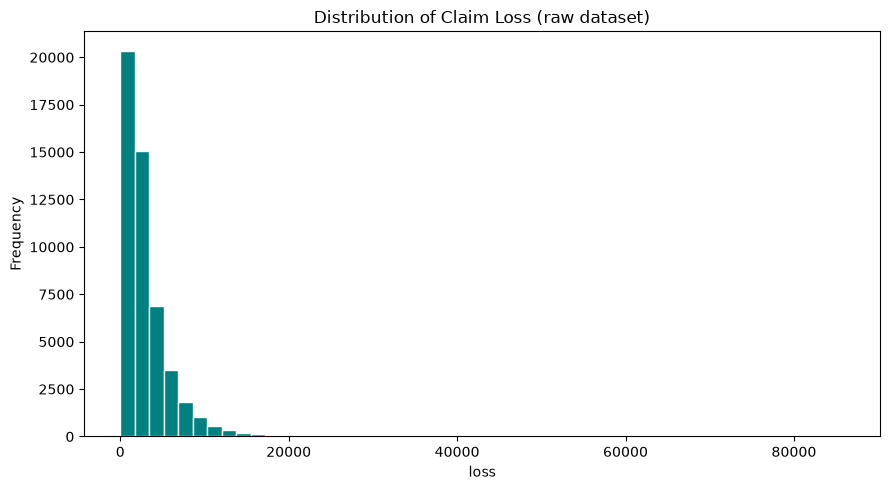

Saved: /Users/padaltiruvinayak/Desktop/Credit ML/Outputs/Data_Inspection/claimwise_raw_target_distribution.png


In [10]:
INSPECTION_DIR = OUTPUTS_DIR / "Data_Inspection"
INSPECTION_DIR.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(df_raw["loss"], bins=50, color="teal", edgecolor="white")
ax.set_title("Distribution of Claim Loss (raw dataset)")
ax.set_xlabel("loss")
ax.set_ylabel("Frequency")
fig.tight_layout()
fig.savefig(INSPECTION_DIR / "claimwise_raw_target_distribution.png", dpi=150)
plt.show()
print("Saved:", INSPECTION_DIR / "claimwise_raw_target_distribution.png")

In [11]:
column_summary = pd.DataFrame({
    "column": df_raw.columns,
    "dtype": [str(dtype) for dtype in df_raw.dtypes],
    "missing_values": df_raw.isnull().sum().to_numpy(),
    "unique_values": df_raw.nunique(dropna=False).to_numpy(),
})
summary_path = INSPECTION_DIR / "claimwise_raw_column_summary.csv"
column_summary.to_csv(summary_path, index=False)

print("Saved column-level summary for", len(column_summary), "columns to:")
print(summary_path)
display(column_summary.head(10))

Saved column-level summary for 132 columns to:
/Users/padaltiruvinayak/Desktop/Credit ML/Outputs/Data_Inspection/claimwise_raw_column_summary.csv


,column,dtype,missing_values,unique_values
0,id,int64,0,50000
1,cat1,str,0,2
2,cat2,str,0,2
3,cat3,str,0,2
4,cat4,str,0,2
5,cat5,str,0,2
6,cat6,str,0,2
7,cat7,str,0,2
8,cat8,str,0,2
9,cat9,str,0,2


## 6. Conclusion

The raw ClaimWise dataset was audited **read-only** from `Dataset/01_raw_claimwise_50000.csv`.
Verified in this run:

| Property | Actual value |
|---|---:|
| Rows | 50,000 |
| Columns | 132 |
| Categorical columns (`cat1`..`cat116`) | 116 |
| Continuous columns (`cont1`..`cont14`) | 14 |
| Identifier column | `id` (1 numeric column) |
| Target column | `loss` |
| Missing values | 0 |
| Duplicate rows | 0 |
| `loss` range | 10.00 to 85,923.56 (mean 3,035.01, skew 3.79) |

Nothing was modified. The column-level audit is saved to
`Outputs/Data_Inspection/claimwise_raw_column_summary.csv` and the target histogram to
`Outputs/Data_Inspection/claimwise_raw_target_distribution.png`.

Next: `02_ClaimWise_Data_Preprocessing.ipynb`.